# S2 | Model Analysis

Analyzes all available model results across three inference tiers and three text-only conditions.

## Tiers
| Tier | Description | Models |
|---|---|---|
| **pretrained** | Full VLM with vision encoder (image or blank PNG) | 11 models |
| **lm_decoder** | VLM loaded, vision encoder bypassed at runtime | 11 models |
| **backbone** | Standalone LLM (never co-trained with vision) | 8 models |

## Conditions
| Condition | File | Description |
|---|---|---|
| `control` | `vqa_1k_control.jsonl` | Original question, original image |
| `blind` | `vqa_1k_control_blind.jsonl` | Original question, no image |
| `inst_blind` | `vqa_1k_control_inst_blind.jsonl` | + instruction: *imagine an image* |
| `push` | `vqa_1k_control_push.jsonl` | + instruction: *use language knowledge* |

All accuracy computed with VQA soft-match scorer (VQAAnswerMapper).
All analyses run on the **full 1k pool** and the **100-question S2 sample**.

In [1]:
import json
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr

sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

mapper = VQAAnswerMapper()

LOGIT_DIR  = '/home/david/Desktop/yuna/HPA/evaluation/logits'
S2_CSV     = '/home/david/Desktop/yuna/HPA/experiment/s2.csv'
SEM_PATH   = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

# S2 sample question IDs
s2_df  = pd.read_csv(S2_CSV)
S2_QIDS = set(s2_df['question_id'].tolist())
print(f'S2 sample: {len(S2_QIDS)} questions')

# Semantics for grouping
sem_df = pd.read_json(SEM_PATH, lines=True)[['question_id','ent','op','w','ans']]
qid2op  = dict(zip(sem_df['question_id'], sem_df['op']))
qid2ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid2w   = dict(zip(sem_df['question_id'], sem_df['w']))

# Model configuration
PRETRAINED_MODELS = [
    'InternVL3_5-1B', 'InternVL3_5-2B', 'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-8B-Instruct',
    'llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf',
    'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-vicuna-13b-hf',
]
LMDECODER_MODELS = [
    'InternVL3_5-1B', 'InternVL3_5-2B', 'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-8B-Instruct',
    'llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf',
    'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-vicuna-13b-hf',
]
BACKBONE_MODELS = [
    'Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-32B',
    'vicuna-7b-v1.5', 'vicuna-13b-v1.5', 'Mistral-7B-Instruct-v0.2',
]
CONDITIONS = ['control', 'blind', 'inst_blind', 'push']
COND_FILE  = {'control': 'vqa_1k_control.jsonl',
              'blind':     'vqa_1k_control_blind.jsonl',
              'inst_blind':'vqa_1k_control_inst_blind.jsonl',
              'push':      'vqa_1k_control_push.jsonl'}
COND_LABEL = {'control':'Original\n(+image)', 'blind':'Blind',
               'inst_blind':'Inst-Blind', 'push':'Push'}

def clean_think(s):
    """Strip <think>...</think> tags from Qwen3 backbone outputs."""
    return re.sub(r'<think>.*?</think>', '', s, flags=re.DOTALL).strip()

def load_acc(tier_dir, model, condition, qid_filter=None):
    """Load per-question accuracy for one model×condition. Returns {qid: acc}."""
    path = os.path.join(tier_dir, model, COND_FILE[condition])
    if not os.path.exists(path):
        return {}
    accs = {}
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            if qid_filter and qid not in qid_filter:
                continue
            gt  = mapper.get_answers(qid)
            ga  = ex.get('generated_answers', {})
            raw = ga.get('question', '')
            if 'Qwen3' in model and 'VL' not in model:  # backbone Qwen3
                raw = clean_think(raw)
            accs[qid] = vqa_accuracy(raw.strip(), gt)
    return accs

print('Setup complete.')

S2 sample: 100 questions
Setup complete.


---
## 1. Accuracy by Condition — All Tiers

Mean accuracy across all 1k questions for each model × condition.
Shows the three text-only conditions: `blind` (no image), `inst_blind` (no image + imagine instruction), `push` (no image + language-prior instruction).
The `control` condition (with image) serves as the upper-bound reference.

In [2]:
# ── Load all accuracy data ────────────────────────────────────────────────────
rows = []
tier_map = {
    'pretrained': (os.path.join(LOGIT_DIR, 'pretrained'),            PRETRAINED_MODELS),
    'lm_decoder': (os.path.join(LOGIT_DIR, 'lm_decoder', 'pretrained'), LMDECODER_MODELS),
    'backbone':   (os.path.join(LOGIT_DIR, 'backbone', 'pretrained'),   BACKBONE_MODELS),
}

for tier, (tdir, models) in tier_map.items():
    for model in models:
        for cond in CONDITIONS:
            accs = load_acc(tdir, model, cond)
            if not accs: continue
            rows.append({
                'tier': tier, 'model': model, 'condition': cond,
                'n': len(accs), 'acc': float(np.mean(list(accs.values())))
            })

acc_df = pd.DataFrame(rows)
print(f'Loaded {len(acc_df)} model×condition entries')
print(acc_df.groupby(['tier','condition'])['acc'].agg(['mean','count']).round(3))

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations


Loaded 72 model×condition entries
                        mean  count
tier       condition               
backbone   blind       0.031      8
           control     0.035      7
           inst_blind  0.064      7
lm_decoder blind       0.383     10
           control     0.352      1
           inst_blind  0.381     10
pretrained blind       0.349     10
           control     0.802      9
           inst_blind  0.352     10


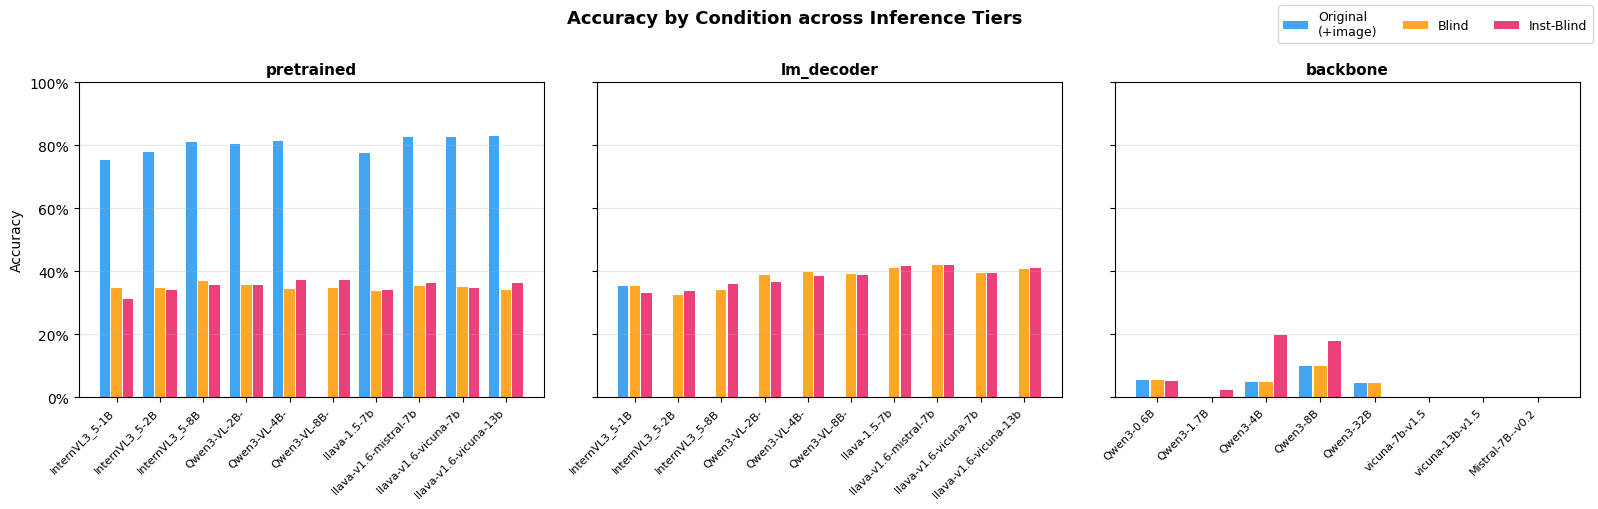

Saved: s2_acc_by_condition.png


In [3]:
# ── Bar chart: accuracy by tier × condition ───────────────────────────────────
CONDS_PLOT = [c for c in CONDITIONS if c in acc_df['condition'].unique()]
TIERS = ['pretrained', 'lm_decoder', 'backbone']
COLORS = {'control':'#2196F3', 'blind':'#FF9800', 'inst_blind':'#E91E63', 'push':'#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, tier in zip(axes, TIERS):
    sub = acc_df[acc_df['tier'] == tier]
    models = sub['model'].unique()
    x = np.arange(len(models))
    w = 0.8 / len(CONDS_PLOT)
    for i, cond in enumerate(CONDS_PLOT):
        vals = [sub[sub['model']==m]['acc'].values[0]
                if len(sub[(sub['model']==m)&(sub['condition']==cond)]) > 0
                else np.nan
                for m in models]
        cvals = [sub[(sub['model']==m)&(sub['condition']==cond)]['acc'].values[0]
                 if len(sub[(sub['model']==m)&(sub['condition']==cond)]) > 0 else np.nan
                 for m in models]
        ax.bar(x + i*w - (len(CONDS_PLOT)-1)*w/2, cvals, w*0.9,
               color=COLORS[cond], label=COND_LABEL[cond], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('Instruct','').replace('-hf','') for m in models],
                        rotation=45, ha='right', fontsize=8)
    ax.set_title(tier, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('Accuracy', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
seen = {};
[seen.update({l: h}) for h, l in zip(handles, labels)]
fig.legend(seen.values(), seen.keys(), loc='upper right', fontsize=9, ncol=len(CONDS_PLOT))
fig.suptitle('Accuracy by Condition across Inference Tiers', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/s2_acc_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2_acc_by_condition.png')

---
## 2. Condition Effect Summary Table

For each model, computes the accuracy under each condition and key deltas:
- **Blind exploit rate** = `blind_acc` (model exploits prior without any instruction)
- **Inst gain** = `inst_blind - blind` (how much the imagine-instruction boosts accuracy)
- **Multimodal gain** = `control - inst_blind` (benefit of actually seeing the image)
- **Push vs inst** = `push - inst_blind` (difference between two instruction framings)

In [4]:
# ── Condition effect summary table ───────────────────────────────────────────
summary_rows = []
for tier, (tdir, models) in tier_map.items():
    for model in models:
        sub = acc_df[(acc_df['tier']==tier) & (acc_df['model']==model)]
        row = {'tier': tier, 'model': model}
        for cond in CONDITIONS:
            v = sub[sub['condition']==cond]['acc']
            row[cond] = round(v.values[0], 3) if len(v) > 0 else None
        if row.get('blind') is not None and row.get('inst_blind') is not None:
            row['inst_gain'] = round(row['inst_blind'] - row['blind'], 3)
        if row.get('control') is not None and row.get('inst_blind') is not None:
            row['mm_gain']   = round(row['control'] - row['inst_blind'], 3)
        if row.get('push') is not None and row.get('inst_blind') is not None:
            row['push_vs_inst'] = round(row['push'] - row['inst_blind'], 3)
        summary_rows.append(row)

sum_df = pd.DataFrame(summary_rows)

display_cols = ['tier','model','control','blind','inst_blind','push','inst_gain','mm_gain','push_vs_inst']
display_cols = [c for c in display_cols if c in sum_df.columns]

pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
print(sum_df[display_cols].sort_values(['tier','blind'], ascending=[True, False]).to_string(index=False))

      tier                    model  control  blind  inst_blind push  inst_gain  mm_gain
  backbone                 Qwen3-8B    0.099  0.099       0.178 None      0.079   -0.079
  backbone               Qwen3-0.6B    0.053  0.053       0.050 None     -0.003    0.003
  backbone                 Qwen3-4B    0.049  0.049       0.196 None      0.147   -0.147
  backbone                Qwen3-32B    0.046  0.046         NaN None        NaN      NaN
  backbone               Qwen3-1.7B    0.001  0.001       0.022 None      0.021   -0.021
  backbone           vicuna-7b-v1.5    0.000  0.000       0.000 None      0.000    0.000
  backbone          vicuna-13b-v1.5      NaN  0.000       0.000 None      0.000      NaN
  backbone Mistral-7B-Instruct-v0.2    0.000  0.000       0.000 None      0.000    0.000
lm_decoder llava-v1.6-mistral-7b-hf      NaN  0.420       0.420 None      0.000      NaN
lm_decoder          llava-1.5-7b-hf      NaN  0.409       0.415 None      0.006      NaN
lm_decoder llava-v1.6

---
## 3. Tier Comparison: VLM vs LM-Decoder vs Backbone

For paired models (same weights, different inference path), compares blind and inst_blind accuracy.
Tests whether co-training with vision inflates language-prior exploitation.

Paired models (VLM + lm_decoder): 10


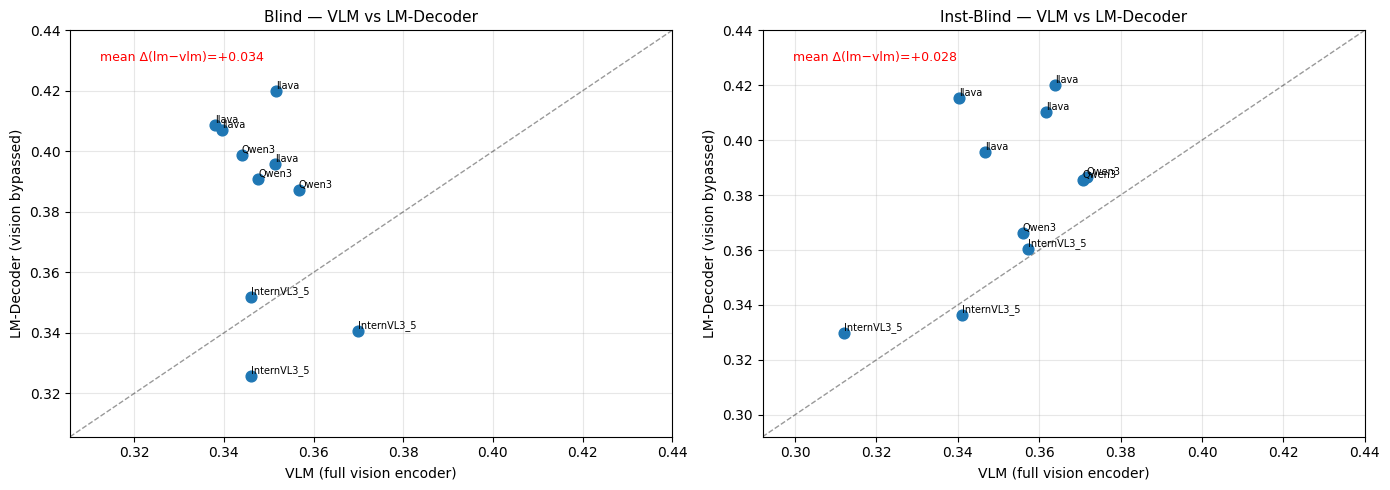

Saved: s2_tier_comparison.png


In [5]:
# ── Paired tier comparison ────────────────────────────────────────────────────
# Models that have both pretrained and lm_decoder results
paired_models = [
    m for m in PRETRAINED_MODELS
    if m in LMDECODER_MODELS and
    len(acc_df[(acc_df['tier']=='pretrained')&(acc_df['model']==m)]) > 0 and
    len(acc_df[(acc_df['tier']=='lm_decoder')&(acc_df['model']==m)]) > 0
]
print(f'Paired models (VLM + lm_decoder): {len(paired_models)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cond in zip(axes, ['blind', 'inst_blind']):
    vlm_vals, lm_vals = [], []
    for m in paired_models:
        v = acc_df[(acc_df['tier']=='pretrained')&(acc_df['model']==m)&(acc_df['condition']==cond)]['acc']
        l = acc_df[(acc_df['tier']=='lm_decoder')&(acc_df['model']==m)&(acc_df['condition']==cond)]['acc']
        if len(v) and len(l):
            vlm_vals.append(v.values[0]); lm_vals.append(l.values[0])

    ax.scatter(vlm_vals, lm_vals, s=60, zorder=3)
    for i, m in enumerate([m for m in paired_models if i < len(vlm_vals)]):
        if i < len(vlm_vals):
            ax.annotate(m.split('-')[0], (vlm_vals[i], lm_vals[i]),
                        fontsize=7, ha='left', va='bottom')
    lim = [min(vlm_vals+lm_vals)-0.02, max(vlm_vals+lm_vals)+0.02]
    ax.plot(lim, lim, 'k--', alpha=0.4, lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('VLM (full vision encoder)', fontsize=10)
    ax.set_ylabel('LM-Decoder (vision bypassed)', fontsize=10)
    ax.set_title(f'{COND_LABEL[cond]} — VLM vs LM-Decoder', fontsize=11)
    ax.grid(alpha=0.3)
    mean_diff = np.mean(np.array(lm_vals) - np.array(vlm_vals))
    ax.text(0.05, 0.95, f'mean Δ(lm−vlm)={mean_diff:+.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            color='red' if mean_diff > 0 else 'blue')

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/s2_tier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2_tier_comparison.png')

---
## 4. Degradation Ladder — Accuracy by Control Variant

For the **5-step control hierarchy** (original → deictic_removed → object_removed → weaker_object → pronominalized),
tracks how accuracy drops as the question is progressively stripped of visual grounding.
Shown separately for `blind` and `inst_blind` conditions on the S2 sample questions.

In [6]:
# ── Load full control-type accuracy for S2 sample ────────────────────────────
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
CT_LABELS     = ['Original', 'Deictic\nremoved', 'Object\nremoved', 'Weaker\nobject', 'Pronominalized']

def load_ct_acc(tier_dir, model, condition_suffix, qid_filter=None):
    """Load per-CT accuracy from a control JSONL file."""
    path = os.path.join(tier_dir, model, f'vqa_1k_control{condition_suffix}.jsonl')
    if not os.path.exists(path): return {}
    ct_acc = defaultdict(list)
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            if qid_filter and qid not in qid_filter: continue
            gt  = mapper.get_answers(qid)
            ga  = ex.get('generated_answers', {})
            for ct in CONTROL_TYPES:
                raw = ga.get(ct, '')
                if 'Qwen3' in model and 'VL' not in model:
                    raw = clean_think(raw)
                ct_acc[ct].append(vqa_accuracy(raw.strip(), gt))
    return {ct: float(np.mean(v)) for ct, v in ct_acc.items() if v}

# Load degradation for pretrained models on S2 sample
COMPLETE_MODELS = [
    m for m in PRETRAINED_MODELS
    if os.path.exists(os.path.join(LOGIT_DIR, 'pretrained', m, 'vqa_1k_control.jsonl')) and
    os.path.getsize(os.path.join(LOGIT_DIR, 'pretrained', m, 'vqa_1k_control.jsonl')) > 100000
]
print(f'Complete pretrained models (have full control JSONL): {COMPLETE_MODELS}')

deg_data = {}  # model -> cond_suffix -> {ct: mean_acc}
for model in COMPLETE_MODELS:
    deg_data[model] = {}
    for suffix in ['', '_blind', '_inst_blind']:
        ct_accs = load_ct_acc(os.path.join(LOGIT_DIR,'pretrained'), model, suffix, S2_QIDS)
        if ct_accs: deg_data[model][suffix] = ct_accs

print(f'Loaded degradation for {len(deg_data)} models')

Complete pretrained models (have full control JSONL): ['InternVL3_5-1B', 'InternVL3_5-2B', 'InternVL3_5-8B', 'Qwen3-VL-2B-Instruct', 'Qwen3-VL-4B-Instruct', 'llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf', 'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-vicuna-13b-hf']


Loaded degradation for 9 models


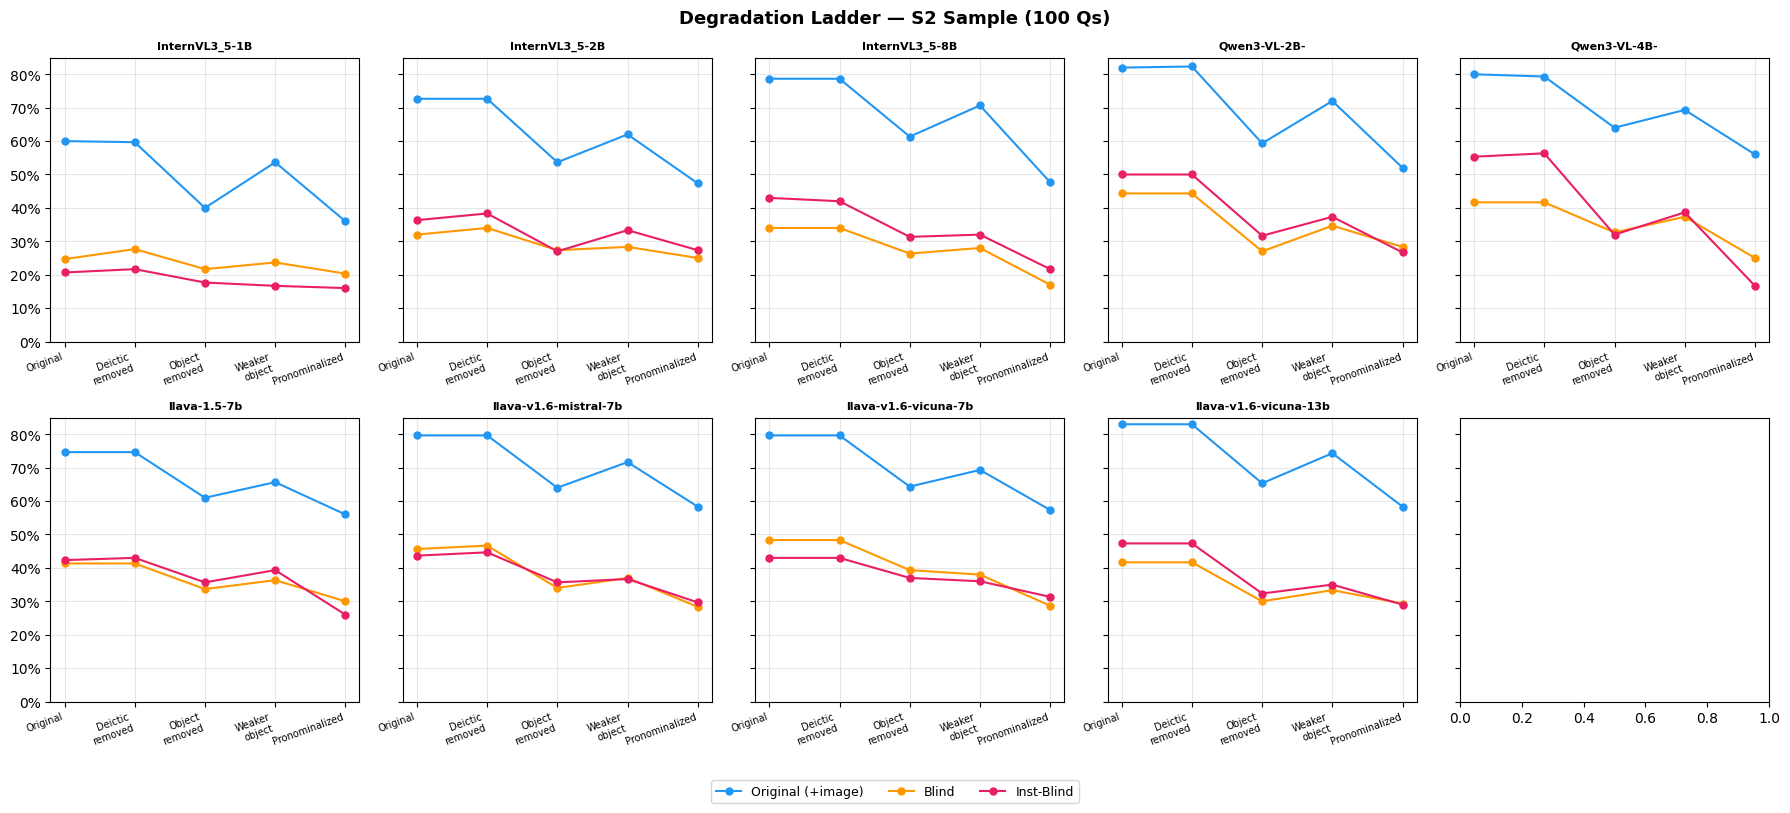

In [7]:
# ── Degradation ladder plot ───────────────────────────────────────────────────
SUFFIX_LABEL = {'': 'Original (+image)', '_blind': 'Blind', '_inst_blind': 'Inst-Blind'}
SUFFIX_COLOR = {'': '#2196F3', '_blind': '#FF9800', '_inst_blind': '#E91E63'}
x = np.arange(len(CONTROL_TYPES))

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=True)
for idx, model in enumerate(COMPLETE_MODELS[:10]):
    ax = axes[idx // 5][idx % 5]
    for suffix, label in SUFFIX_LABEL.items():
        if suffix not in deg_data[model]: continue
        vals = [deg_data[model][suffix].get(ct, np.nan) for ct in CONTROL_TYPES]
        ax.plot(x, vals, 'o-', label=label, color=SUFFIX_COLOR[suffix], lw=1.5, ms=5)
    ax.set_xticks(x)
    ax.set_xticklabels(CT_LABELS, fontsize=7, rotation=20, ha='right')
    ax.set_title(model.replace('-hf','').replace('Instruct',''), fontsize=8, fontweight='bold')
    ax.set_ylim(0, 0.85)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(alpha=0.3)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Degradation Ladder — S2 Sample (100 Qs)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/s2_degradation_ladder.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Instruction Effect: Blind → Inst-Blind

For each model, measures how much a single instruction sentence (*"imagine an image"*)
changes accuracy and answer behavior.
- **Inst gain**: accuracy boost from blind → inst_blind
- **Answer change rate**: fraction of questions where the predicted answer changes
- **Soft abstention collapse**: models that output 'nothing'/'none' under blind may stop doing so under inst_blind

In [8]:
# ── Inst gain + answer change rate ────────────────────────────────────────────
ABSTAIN_WORDS = {'nothing','none','nowhere','unanswerable','unknown','unclear',
                 'cannot','can\'t','no image','blank','n/a','not visible','not shown'}

def is_abstain(ans):
    a = ans.lower().strip()
    return any(w in a for w in ABSTAIN_WORDS)

change_rows = []
for tier, (tdir, models) in tier_map.items():
    for model in models:
        bp = os.path.join(tdir, model, 'vqa_1k_control_blind.jsonl')
        ip = os.path.join(tdir, model, 'vqa_1k_control_inst_blind.jsonl')
        if not (os.path.exists(bp) and os.path.exists(ip)): continue

        blind_ans, inst_ans = {}, {}
        for path, d in [(bp, blind_ans), (ip, inst_ans)]:
            with open(path) as f:
                for line in f:
                    ex = json.loads(line)
                    raw = ex.get('generated_answers',{}).get('question','')
                    if 'Qwen3' in model and 'VL' not in model:
                        raw = clean_think(raw)
                    d[ex['question_id']] = raw.strip().lower()

        common = set(blind_ans) & set(inst_ans)
        if not common: continue

        changed     = sum(blind_ans[q] != inst_ans[q] for q in common)
        abst_blind  = sum(is_abstain(blind_ans[q]) for q in common)
        abst_inst   = sum(is_abstain(inst_ans[q])  for q in common)

        blind_acc_v = float(np.mean([vqa_accuracy(blind_ans[q], mapper.get_answers(q)) for q in common]))
        inst_acc_v  = float(np.mean([vqa_accuracy(inst_ans[q],  mapper.get_answers(q)) for q in common]))

        change_rows.append({
            'tier': tier, 'model': model,
            'blind_acc': round(blind_acc_v, 3),
            'inst_acc':  round(inst_acc_v, 3),
            'inst_gain': round(inst_acc_v - blind_acc_v, 3),
            'change_rate': round(changed / len(common), 3),
            'abst_blind': round(abst_blind / len(common), 3),
            'abst_inst':  round(abst_inst  / len(common), 3),
            'abst_collapse': round((abst_blind - abst_inst) / max(abst_blind, 1), 3),
        })

chg_df = pd.DataFrame(change_rows)
print(chg_df[['tier','model','blind_acc','inst_acc','inst_gain','change_rate',
               'abst_blind','abst_inst','abst_collapse']]
      .sort_values(['tier','inst_gain'], ascending=[True, False])
      .to_string(index=False))

      tier                    model  blind_acc  inst_acc  inst_gain  change_rate  abst_blind  abst_inst  abst_collapse
  backbone                 Qwen3-4B      0.049     0.196      0.148        0.679       0.017      0.006          0.647
  backbone                 Qwen3-8B      0.099     0.178      0.079        0.575       0.117      0.041          0.650
  backbone               Qwen3-1.7B      0.001     0.022      0.020        0.744       0.118      0.050          0.576
  backbone           vicuna-7b-v1.5      0.000     0.000      0.000        0.000       0.000      0.000          0.000
  backbone          vicuna-13b-v1.5      0.000     0.000      0.000        0.138       0.008      0.004          0.500
  backbone Mistral-7B-Instruct-v0.2      0.000     0.000      0.000        0.964       0.420      0.310          0.262
  backbone               Qwen3-0.6B      0.053     0.050     -0.003        0.256       0.002      0.001          0.500
lm_decoder           InternVL3_5-8B      0.341  

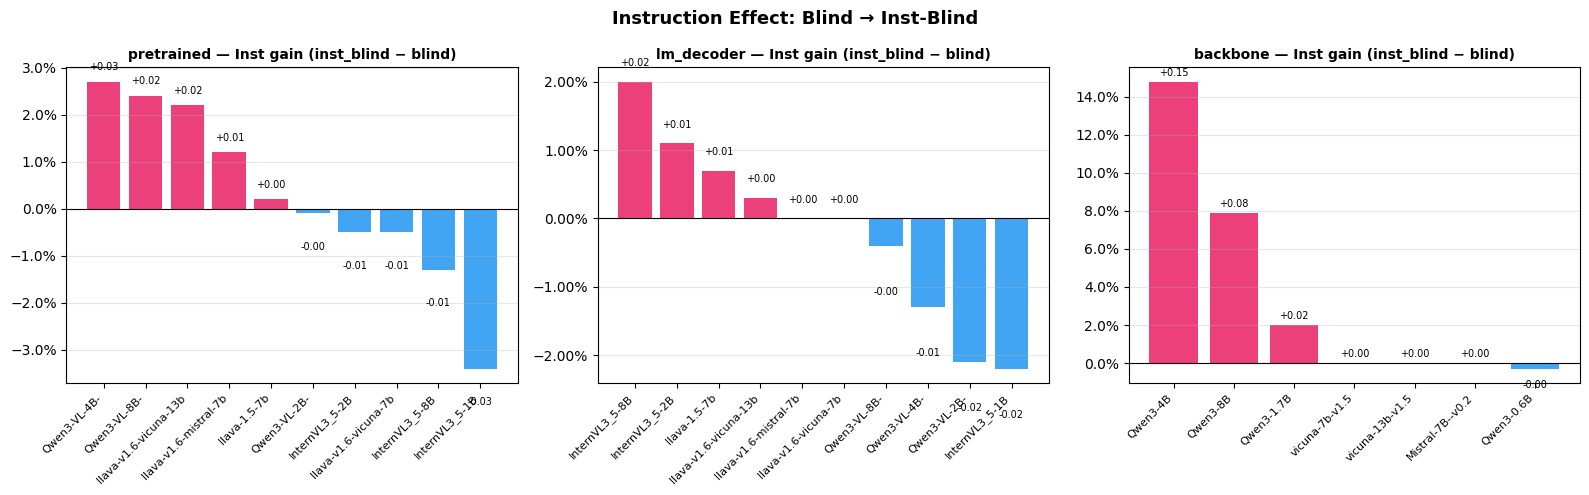

In [9]:
# ── Inst gain bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, tier in zip(axes, TIERS):
    sub = chg_df[chg_df['tier'] == tier].sort_values('inst_gain', ascending=False)
    if sub.empty: ax.set_visible(False); continue
    x = np.arange(len(sub))
    bars = ax.bar(x, sub['inst_gain'], color=[
        '#E91E63' if v > 0 else '#2196F3' for v in sub['inst_gain']
    ], alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('-hf','').replace('Instruct','') for m in sub['model']],
                        rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{tier} — Inst gain (inst_blind − blind)', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, sub['inst_gain']):
        ax.text(bar.get_x()+bar.get_width()/2, v + (0.002 if v >= 0 else -0.006),
                f'{v:+.2f}', ha='center', fontsize=7, va='bottom' if v >= 0 else 'top')

plt.suptitle('Instruction Effect: Blind → Inst-Blind', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/s2_inst_gain.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Answer Distribution by Condition

Top-10 most frequent answers per condition for each tier.
Reveals systematic biases: color bias ("black"), position bias ("left"), numeric bias ("1", "2").

In [10]:
# ── Top answers per condition, averaged across models ────────────────────────
from collections import Counter

for tier, (tdir, models) in tier_map.items():
    print(f'\n=== {tier} ===')
    for cond in ['blind', 'inst_blind']:
        all_ans = []
        for model in models:
            path = os.path.join(tdir, model, COND_FILE[cond])
            if not os.path.exists(path): continue
            with open(path) as f:
                for line in f:
                    ex = json.loads(line)
                    raw = ex.get('generated_answers',{}).get('question','')
                    if 'Qwen3' in model and 'VL' not in model:
                        raw = clean_think(raw)
                    all_ans.append(raw.strip().lower())
        if not all_ans: continue
        top10 = Counter(all_ans).most_common(10)
        pcts  = [(a, n/len(all_ans)*100) for a, n in top10]
        print(f'  {cond}: ' + ' | '.join(f'"{a}" {p:.1f}%' for a, p in pcts))


=== pretrained ===


  blind: "no" 28.5% | "yes" 10.4% | "black" 8.2% | "0" 8.2% | "nothing" 4.9% | "none" 3.0% | "white" 1.6% | "nowhere" 1.2% | "1" 1.1% | "2" 0.6%


  inst_blind: "no" 27.8% | "yes" 11.0% | "0" 7.6% | "black" 6.9% | "nothing" 2.6% | "white" 2.0% | "none" 1.6% | "zero" 0.8% | "red" 0.7% | "2" 0.6%

=== lm_decoder ===


  blind: "yes" 26.1% | "no" 12.6% | "0" 3.5% | "white" 3.2% | "black" 2.5% | "1" 2.3% | "blue" 1.6% | "2" 1.0% | "nothing" 0.9% | "red" 0.7%


  inst_blind: "yes" 27.7% | "no" 11.0% | "white" 3.4% | "0" 2.9% | "black" 2.3% | "1" 2.1% | "blue" 1.5% | "2" 1.0% | "red" 0.9% | "grass" 0.6%

=== backbone ===


  blind: "" 23.4% | "yes." 11.0% | "no." 3.4% | "red" 1.6% | "unknown" 1.1% | "blue" 0.8% | "possibly." 0.6% | "white" 0.6% | "yes" 0.4% | "1" 0.4%


  inst_blind: "" 27.6% | "yes." 6.1% | "yes" 4.2% | "red" 1.9% | "no." 1.0% | "white" 0.9% | "no" 0.8% | "sun" 0.6% | "blue" 0.5% | "black" 0.4%


---
## 7. Op-Type & Entity-Group Analysis

Breaks down accuracy by **operator type** (attr / ident / spat / act / count / cause)
and **entity group** (object / person / other_ent) for **all 1000 questions**.
Shows which question categories are most exploitable from language priors alone.
Run on complete pretrained VLMs only (models with full control JSONL).

In [11]:
# ── Per-op and per-ent accuracy on all 1000 questions ───────────────────────
OP_GROUPS  = ['attr', 'ident', 'spat', 'act', 'count', 'cause', 'comp', 'other']
ENT_GROUPS = ['object', 'person', 'animal', 'food', 'place', 'vehicle', 'other']
ENT3_MAP   = {'object':'object','person':'person',
              'animal':'other_ent','food':'other_ent','place':'other_ent',
              'vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}

all_qids = set(qid2op.keys())  # full 1k pool

op_rows, ent_rows = [], []
for model in COMPLETE_MODELS:
    for suffix, cond_label in [('_blind','blind'), ('_inst_blind','inst_blind')]:
        path = os.path.join(LOGIT_DIR, 'pretrained', model, f'vqa_1k_control{suffix}.jsonl')
        if not os.path.exists(path): continue
        op_accs  = defaultdict(list)
        ent_accs = defaultdict(list)
        with open(path) as f:
            for line in f:
                ex  = json.loads(line)
                qid = ex['question_id']
                gt  = mapper.get_answers(qid)
                raw = ex.get('generated_answers', {}).get('question', '').strip()
                acc = vqa_accuracy(raw, gt)
                op  = qid2op.get(qid, 'other')
                ent = ENT3_MAP.get(qid2ent.get(qid, 'other'), 'other_ent')
                op_accs[op].append(acc)
                ent_accs[ent].append(acc)
        for op, accs in op_accs.items():
            op_rows.append({'model': model, 'condition': cond_label,
                            'op': op, 'acc': float(np.mean(accs)), 'n': len(accs)})
        for ent, accs in ent_accs.items():
            ent_rows.append({'model': model, 'condition': cond_label,
                             'ent': ent, 'acc': float(np.mean(accs)), 'n': len(accs)})

op_df2  = pd.DataFrame(op_rows)
ent_df2 = pd.DataFrame(ent_rows)

print('=== Mean accuracy by op type (all 1000 Qs, pretrained VLMs) ===')
op_pivot = op_df2.groupby(['condition','op'])['acc'].mean().unstack('op').round(3)
print(op_pivot[[o for o in OP_GROUPS if o in op_pivot.columns]])

print('\n=== Mean accuracy by entity group (all 1000 Qs) ===')
ent_pivot = ent_df2.groupby(['condition','ent'])['acc'].mean().unstack('ent').round(3)
print(ent_pivot)


=== Mean accuracy by op type (all 1000 Qs, pretrained VLMs) ===
op          attr  ident  spat   act  count  cause  comp  other
condition                                                     
blind      0.372  0.242 0.215 0.448  0.229  0.167 0.481  0.559
inst_blind 0.381  0.238 0.233 0.423  0.195  0.127 0.510  0.563

=== Mean accuracy by entity group (all 1000 Qs) ===
ent         object  other_ent  person
condition                            
blind        0.287      0.374   0.396
inst_blind   0.289      0.380   0.385


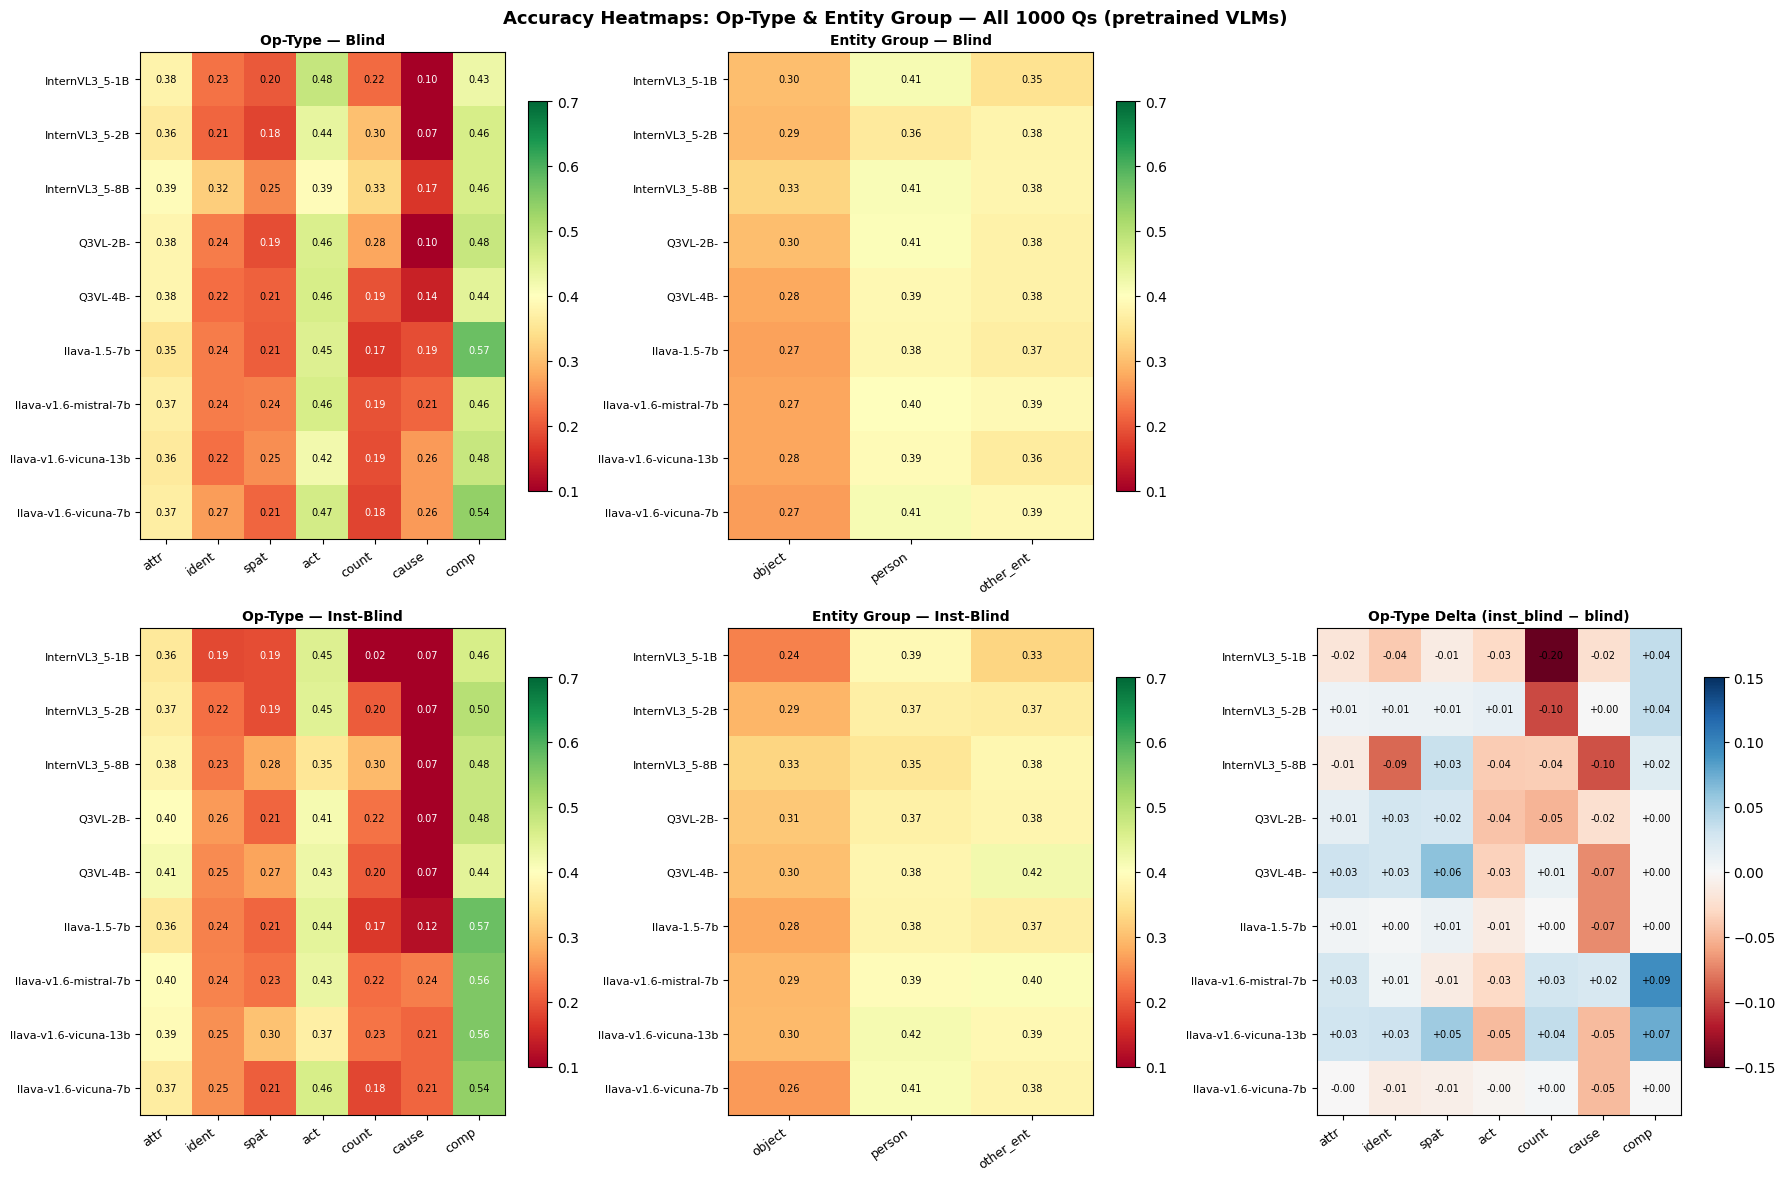

Saved: s2_group_heatmaps.png


In [12]:
# ── Op-type heatmap (blind & inst_blind) ─────────────────────────────────────
def draw_heatmap(ax, df, group_col, groups_show, cond, title):
    sub    = df[df['condition'] == cond]
    pivot  = sub.pivot_table(index='model', columns=group_col, values='acc')
    cols   = [g for g in groups_show if g in pivot.columns]
    pivot  = pivot[cols]
    labels = [m.replace('-hf','').replace('Instruct','').replace('Qwen3-VL-','Q3VL-') for m in pivot.index]
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0.1, vmax=0.7)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(len(pivot.index)):
        for j in range(len(cols)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                        color='black' if 0.2 < v < 0.55 else 'white')
    return im

OP_SHOW  = ['attr', 'ident', 'spat', 'act', 'count', 'cause', 'comp']
ENT_SHOW = ['object', 'person', 'other_ent']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for row_i, cond in enumerate(['blind', 'inst_blind']):
    # Op heatmap (left)
    im1 = draw_heatmap(axes[row_i][0], op_df2, 'op', OP_SHOW, cond,
                       f'Op-Type — {COND_LABEL[cond]}')
    plt.colorbar(im1, ax=axes[row_i][0], shrink=0.8)

    # Ent heatmap (middle)
    im2 = draw_heatmap(axes[row_i][1], ent_df2, 'ent', ENT_SHOW, cond,
                       f'Entity Group — {COND_LABEL[cond]}')
    plt.colorbar(im2, ax=axes[row_i][1], shrink=0.8)

    # Delta heatmap (inst_blind − blind) in bottom row only
    if row_i == 1:
        # op delta
        op_b  = op_df2[op_df2['condition']=='blind'].pivot_table(index='model',columns='op',values='acc')
        op_i  = op_df2[op_df2['condition']=='inst_blind'].pivot_table(index='model',columns='op',values='acc')
        op_d  = (op_i - op_b)[[c for c in OP_SHOW if c in op_b.columns]]
        labels = [m.replace('-hf','').replace('Instruct','').replace('Qwen3-VL-','Q3VL-') for m in op_d.index]
        im3 = axes[1][2].imshow(op_d.values, aspect='auto', cmap='RdBu', vmin=-0.15, vmax=0.15)
        axes[1][2].set_xticks(range(len(op_d.columns)))
        axes[1][2].set_xticklabels(list(op_d.columns), rotation=35, ha='right', fontsize=9)
        axes[1][2].set_yticks(range(len(labels)))
        axes[1][2].set_yticklabels(labels, fontsize=8)
        axes[1][2].set_title('Op-Type Delta (inst_blind − blind)', fontsize=10, fontweight='bold')
        for i in range(len(op_d.index)):
            for j in range(len(op_d.columns)):
                v = op_d.values[i, j]
                if not np.isnan(v):
                    axes[1][2].text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=7)
        plt.colorbar(im3, ax=axes[1][2], shrink=0.8)
    else:
        axes[row_i][2].axis('off')

plt.suptitle('Accuracy Heatmaps: Op-Type & Entity Group — All 1000 Qs (pretrained VLMs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/s2_group_heatmaps.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2_group_heatmaps.png')


---
## 8. Interpretation & Summary

Key findings from the model analysis:

In [13]:
# ── Auto-generate interpretation text ────────────────────────────────────────
if len(chg_df) > 0:
    pt = chg_df[chg_df['tier']=='pretrained']
    bb = chg_df[chg_df['tier']=='backbone']
    ld = chg_df[chg_df['tier']=='lm_decoder']

    print('=== INTERPRETATION ===')
    print()
    print('--- Blind accuracy (language prior exploitation) ---')
    for tier_lbl, sub in [('Pretrained VLM', pt), ('LM-Decoder', ld), ('Backbone', bb)]:
        if sub.empty: continue
        mean_b = sub['blind_acc'].mean()
        best_m = sub.loc[sub['blind_acc'].idxmax(), 'model']
        best_v = sub['blind_acc'].max()
        print(f'  {tier_lbl}: mean blind acc = {mean_b:.3f} | best = {best_m} ({best_v:.3f})')

    print()
    print('--- Instruction effect (blind → inst_blind) ---')
    for tier_lbl, sub in [('Pretrained VLM', pt), ('LM-Decoder', ld), ('Backbone', bb)]:
        if sub.empty: continue
        mean_g = sub['inst_gain'].mean()
        max_g  = sub.loc[sub['inst_gain'].idxmax()]
        print(f'  {tier_lbl}: mean gain = {mean_g:+.3f} | most responsive: {max_g["model"]} ({max_g["inst_gain"]:+.3f})')

    print()
    print('--- Soft abstention collapse ---')
    for tier_lbl, sub in [('Pretrained VLM', pt), ('Backbone', bb)]:
        if sub.empty: continue
        high_abst = sub.nlargest(2, 'abst_blind')[['model','abst_blind','abst_inst','abst_collapse']]
        print(f'  {tier_lbl} highest abstention under blind:')
        for _, r in high_abst.iterrows():
            print(f'    {r["model"]}: blind={r["abst_blind"]:.3f} inst={r["abst_inst"]:.3f} collapse={r["abst_collapse"]:.0%}')

    if 'push_vs_inst' in sum_df.columns and sum_df['push_vs_inst'].notna().any():
        print()
        print('--- Push vs Inst-Blind ---')
        push_sub = sum_df.dropna(subset=['push_vs_inst'])
        mean_d = push_sub['push_vs_inst'].mean()
        print(f'  Mean push − inst_blind = {mean_d:+.3f}')
        print(f'  Positive = push > inst_blind (language framing elicits more prior exploitation)')
        print(f'  Negative = inst_blind > push (imagination instruction more effective)')
else:
    print('No data loaded yet.')

=== INTERPRETATION ===

--- Blind accuracy (language prior exploitation) ---
  Pretrained VLM: mean blind acc = 0.349 | best = InternVL3_5-8B (0.370)
  LM-Decoder: mean blind acc = 0.383 | best = llava-v1.6-mistral-7b-hf (0.420)
  Backbone: mean blind acc = 0.029 | best = Qwen3-8B (0.099)

--- Instruction effect (blind → inst_blind) ---
  Pretrained VLM: mean gain = +0.003 | most responsive: Qwen3-VL-4B-Instruct (+0.027)
  LM-Decoder: mean gain = -0.002 | most responsive: InternVL3_5-8B (+0.020)
  Backbone: mean gain = +0.035 | most responsive: Qwen3-4B (+0.148)

--- Soft abstention collapse ---
  Pretrained VLM highest abstention under blind:
    llava-1.5-7b-hf: blind=0.187 inst=0.158 collapse=16%
    llava-v1.6-vicuna-13b-hf: blind=0.185 inst=0.073 collapse=60%
  Backbone highest abstention under blind:
    Mistral-7B-Instruct-v0.2: blind=0.420 inst=0.310 collapse=26%
    Qwen3-1.7B: blind=0.118 inst=0.050 collapse=58%
